### Importing of libraries


In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### Loading of data

In [114]:

df = pd.read_csv("archive/2019_nCoV_20200121_20200206.csv")


### Explorartory Data Anaylsis

In [115]:
df.columns

Index(['Province/State', 'Country/Region', 'Last Update', 'Confirmed',
       'Suspected', 'Recovered', 'Death'],
      dtype='str')

In [116]:
df.info

<bound method DataFrame.info of      Province/State  Country/Region   Last Update  Confirmed  Suspected  \
0             Hubei  Mainland China  2/5/20 16:43    16678.0        NaN   
1         Guangdong  Mainland China  2/5/20 13:23      895.0        NaN   
2          Zhejiang  Mainland China  2/5/20 15:13      895.0        NaN   
3             Henan  Mainland China  2/5/20 15:03      764.0        NaN   
4             Hunan  Mainland China  2/5/20 15:23      661.0        NaN   
...             ...             ...           ...        ...        ...   
1872   Heilongjiang  Mainland China     1/21/2020        NaN        1.0   
1873            NaN           Japan     1/21/2020        1.0        NaN   
1874            NaN        Thailand     1/21/2020        2.0        NaN   
1875            NaN     South Korea     1/21/2020        1.0        NaN   
1876     Washington   United States     1/21/2020        1.0        NaN   

      Recovered  Death  
0         538.0  479.0  
1          49.0  

In [117]:
df.isnull().sum()

Province/State     459
Country/Region       0
Last Update          0
Confirmed           30
Suspected         1789
Recovered          876
Death              999
dtype: int64

### Data cleaning and preprocessing

In [118]:
df.drop_duplicates(inplace=True)

In [119]:
df["Recovered"] = df["Recovered"].fillna(0)
df["Death"] = df["Death"].fillna(0)

In [120]:
df.dtypes

Province/State        str
Country/Region        str
Last Update           str
Confirmed         float64
Suspected         float64
Recovered         float64
Death             float64
dtype: object

In [121]:
df["Last Update"] = pd.to_datetime(df["Last Update"])

df["Date"] = df["Last Update"].dt.date

/var/folders/1p/fzzh5y9d7_n89hxqvfb_49zc0000gn/T/ipykernel_31231/1314276658.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Last Update"] = pd.to_datetime(df["Last Update"])


In [122]:
df.describe()

,Last Update,Confirmed,Suspected,Recovered,Death
count,1539,1509.000000,86.000000,1539.000000,1539.000000
mean,2020-01-29 12:29:43.781676,186.570577,19.627907,5.048083,3.972710
min,2020-01-21 00:00:00,1.000000,1.000000,0.000000,0.000000
25%,2020-01-26 23:00:00,3.000000,1.000000,0.000000,0.000000
50%,2020-01-29 14:30:00,14.000000,4.000000,0.000000,0.000000
75%,2020-02-01 10:00:00,79.000000,20.000000,1.000000,0.000000
max,2020-02-05 16:43:00,16678.000000,244.000000,538.000000,479.000000
std,NaN,1085.006214,42.134811,30.657664,33.476938


### Data Visualization

In [133]:
daily_data = df.groupby("Date")[["Confirmed", "Recovered", "Death"]].sum().reset_index()

### Daily Confirmed



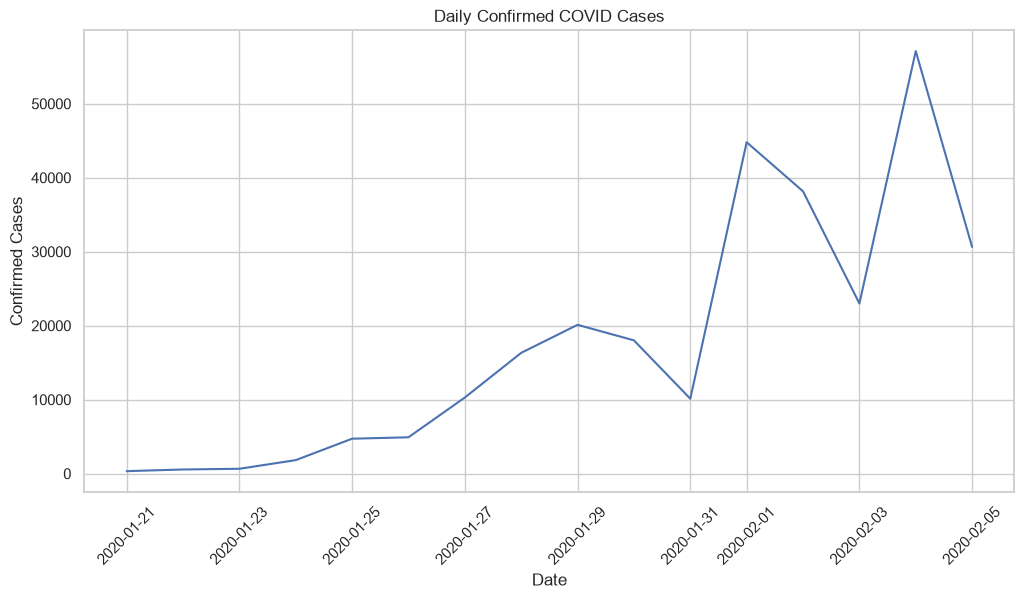

In [134]:
plt.figure(figsize=(12,6))
plt.plot(daily_data["Date"], daily_data["Confirmed"])
plt.title("Daily Confirmed COVID Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

### Daily Death Cases

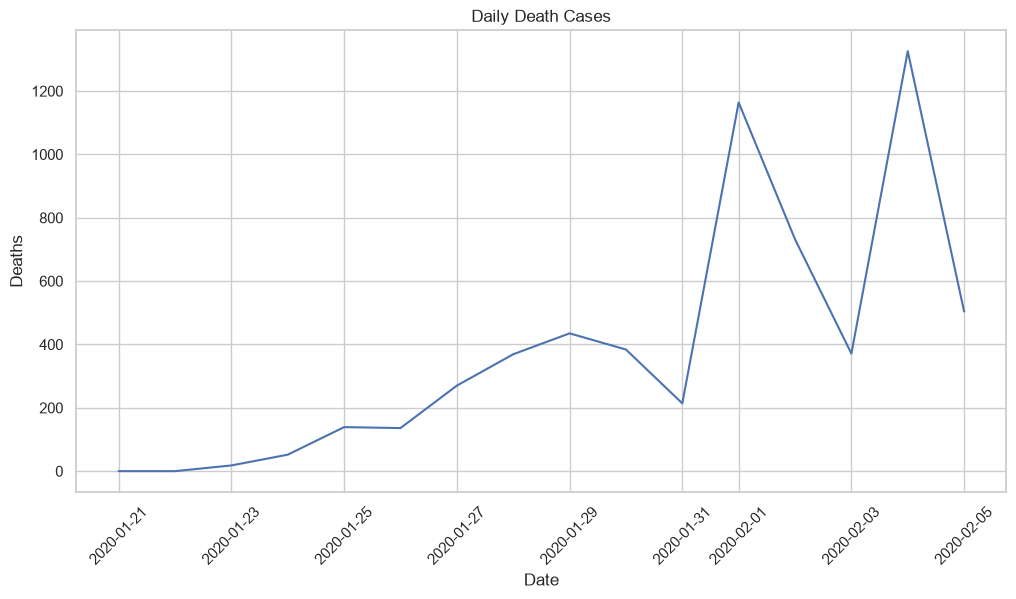

In [135]:
plt.figure(figsize=(12,6))
plt.plot(daily_data["Date"], daily_data["Death"])
plt.title("Daily Death Cases")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.show()

### Daily Recovery Trend

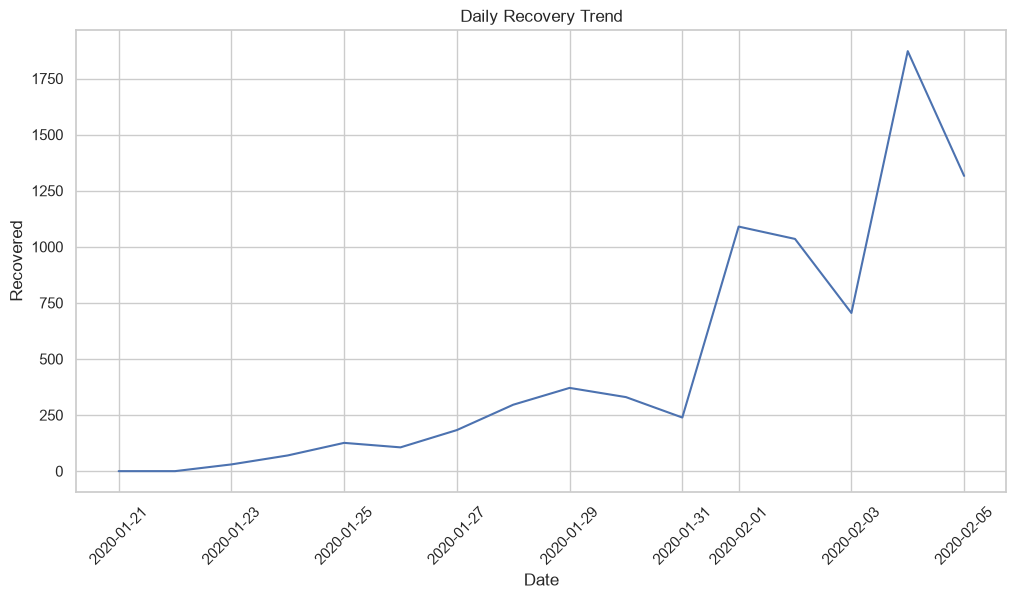

In [136]:
plt.figure(figsize=(12,6))
plt.plot(daily_data["Date"], daily_data["Recovered"])
plt.title("Daily Recovery Trend")
plt.xlabel("Date")
plt.ylabel("Recovered")
plt.xticks(rotation=45)
plt.show()